# Airbnb Market Intelligence

# 04 - Geospatial EDA

## Objectives

- Analyze listing locations
- Compare prices geographically
- Explore city-wise spatial distribution

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/cleaned/listings_cleaned.csv")

print(df.shape)

df.head()

(279712, 32)


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


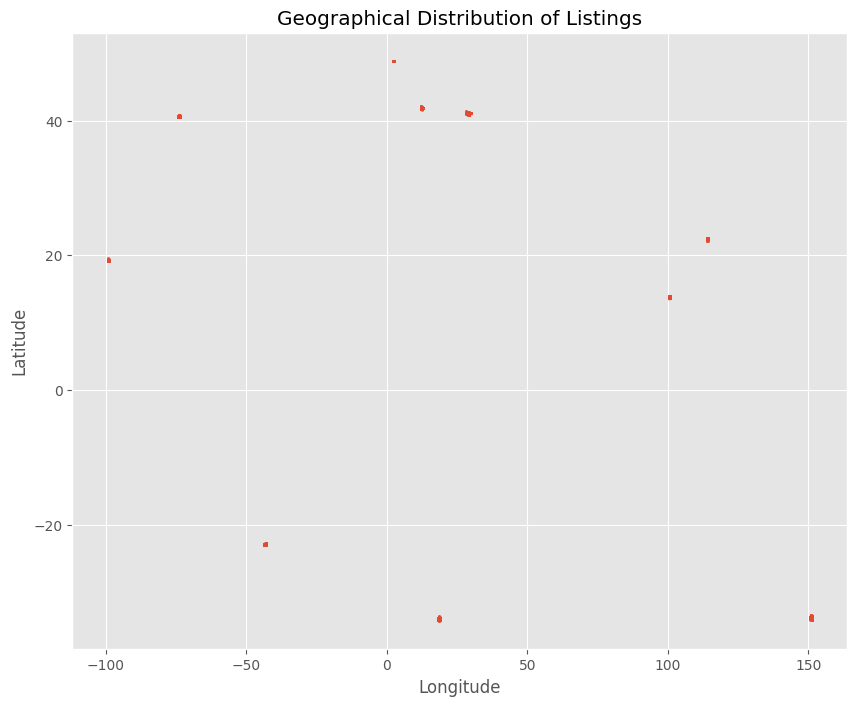

In [3]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    s=2,
    alpha=0.3
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Listings")

plt.show()

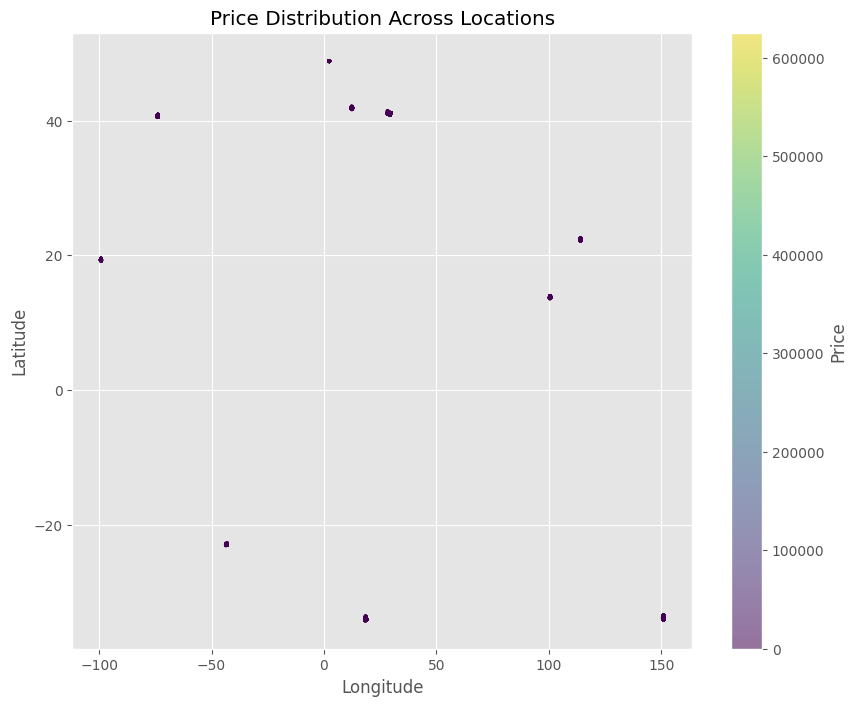

In [4]:
plt.figure(figsize=(10,8))

plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["price"],
    cmap="viridis",
    s=4,
    alpha=0.5
)

plt.colorbar(label="Price")

plt.title("Price Distribution Across Locations")

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

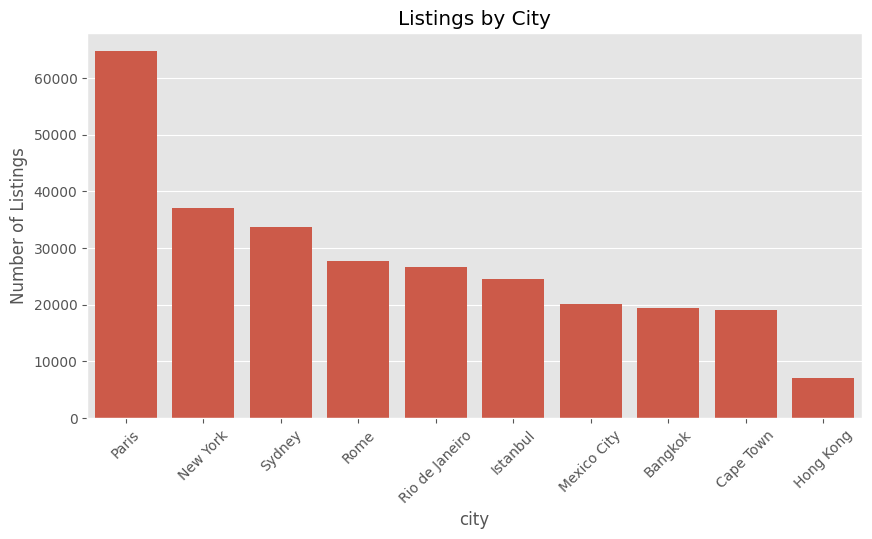

In [5]:
city_count = df["city"].value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=city_count.index,
    y=city_count.values
)

plt.xticks(rotation=45)

plt.title("Listings by City")

plt.ylabel("Number of Listings")

plt.show()

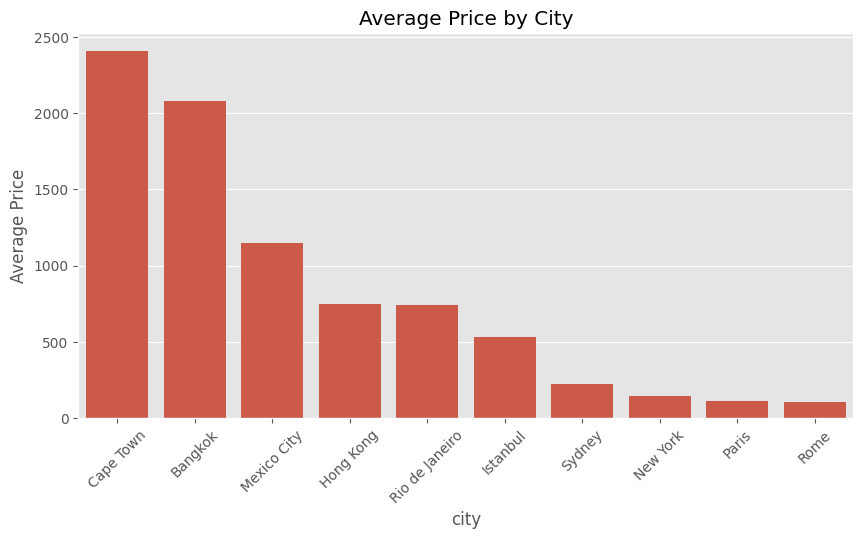

In [6]:
city_price = (
    df.groupby("city")["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=city_price.index,
    y=city_price.values
)

plt.xticks(rotation=45)

plt.title("Average Price by City")

plt.ylabel("Average Price")

plt.show()

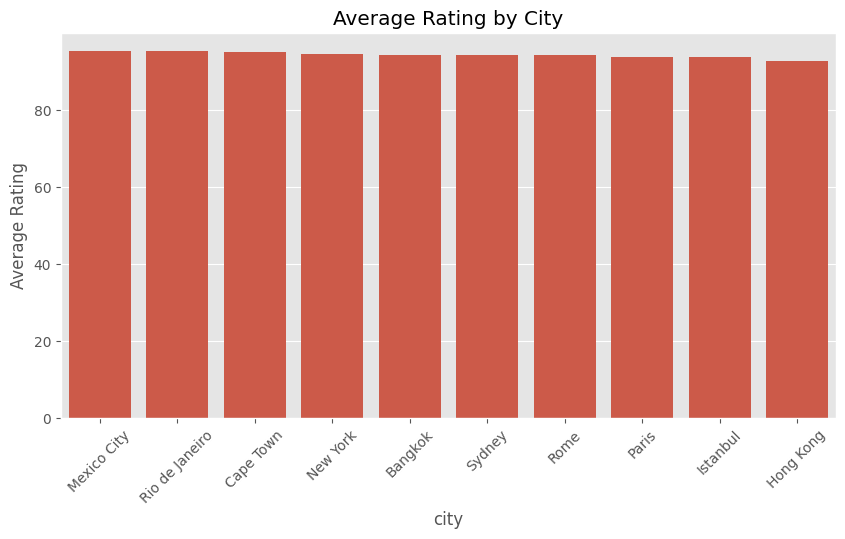

In [7]:
city_rating = (
    df.groupby("city")["review_scores_rating"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=city_rating.index,
    y=city_rating.values
)

plt.xticks(rotation=45)

plt.title("Average Rating by City")

plt.ylabel("Average Rating")

plt.show()

# Business Insights

- Listings are concentrated within major cities.
- Some geographic areas have consistently higher-priced listings.
- Cities differ significantly in listing volume.
- Higher listing density does not always correspond to higher average prices.
- Ratings remain relatively consistent across cities.